In [ ]:

import os
os.makedirs('/content/drive/MyDrive/thesis_resnet50', exist_ok=True)
print(os.listdir('/content/drive/MyDrive/thesis_resnet50'))

[]


In [ ]:
# This copies genimage to Drive (one time only ~2.5GB, takes a few minutes)
!cp -r /content/genimage /content/drive/MyDrive/thesis_resnet50/
print("Dataset saved to Drive!")

Dataset saved to Drive!


### Important Findings

=== PHASE 1 METRICS (Baseline) ===
Accuracy:                  0.4814
AUROC:                     0.3798
ECE:                       0.2895

--- Confidence Analysis ---
Avg Confidence (overall):  0.6824
Avg Confidence (correct):  0.6825
Avg Confidence (wrong):    0.6824

--- High Confidence Errors (threshold > 0.90) ---
High confidence predictions: 111
High confidence errors:      56
Error rate among high conf:  0.5045

In [ ]:

import os
import json

# Paste your actual username and key from the Kaggle API page
kaggle_credentials = {
    "username": "nikythaa",
    "key": "KGAT_bba42e823dbdb9dd8d6584f2efcf08b0"
}

# Save it to the right place
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

!chmod 600 /root/.kaggle/kaggle.json
print("Done!")


Done!


In [ ]:
!kaggle datasets download -d cartografia/unbiased-tiny-genimage -p /content/genimage --unzip


Dataset URL: https://www.kaggle.com/datasets/cartografia/unbiased-tiny-genimage
License(s): CC-BY-NC-SA-4.0
100% 2.35G/2.35G [02:20<00:00, 18.0MB/s]



In [ ]:
import os

base = '/content/genimage'
for folder in os.listdir(base):
    folder_path = os.path.join(base, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f'{folder}: {count} images')

stable_diffusion_v_1_5: 2500 images
Nature: 5828 images
glide: 2500 images
BigGAN: 2500 images
Midjourney: 2500 images
ADM: 2500 images
wukong: 2500 images
VQDM: 2500 images


In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Define paths
base = '/content/genimage'
AI_GENERATORS = ['Midjourney', 'stable_diffusion_v_1_5', 'glide',
                 'wukong', 'BigGAN', 'VQDM', 'ADM']
REAL_FOLDER = 'Nature'

# Collect all image paths and labels
all_paths = []
all_labels = []

# Real images → label 0
for img in os.listdir(os.path.join(base, REAL_FOLDER)):
    all_paths.append(os.path.join(base, REAL_FOLDER, img))
    all_labels.append(0)

# AI images → label 1
for gen in AI_GENERATORS:
    for img in os.listdir(os.path.join(base, gen)):
        all_paths.append(os.path.join(base, gen, img))
        all_labels.append(1)

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print(f"Total images: {len(all_paths)}")
print(f"Real: {np.sum(all_labels==0)}, AI: {np.sum(all_labels==1)}")

Total images: 23328
Real: 5828, AI: 17500


In [ ]:
from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temp
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels  # maintains class balance in each split
)

# Second split: temp → 50% val, 50% test (so 10% val, 10% test overall)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(f"Train: {len(train_paths)} images")
print(f"Val:   {len(val_paths)} images")
print(f"Test:  {len(test_paths)} images")
print()
print(f"Train - Real: {np.sum(train_labels==0)}, AI: {np.sum(train_labels==1)}")
print(f"Val   - Real: {np.sum(val_labels==0)},  AI: {np.sum(val_labels==1)}")
print(f"Test  - Real: {np.sum(test_labels==0)},  AI: {np.sum(test_labels==1)}")

Train: 18662 images
Val:   2333 images
Test:  2333 images

Train - Real: 4662, AI: 14000
Val   - Real: 583,  AI: 1750
Test  - Real: 583,  AI: 1750


In [ ]:
IMG_SIZE = 224  # ResNet-50 input size
BATCH_SIZE = 32

def preprocess_image(path, label):
    # Read and decode image
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    # Resize to ResNet-50 input size
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # Apply ResNet-50 preprocessing
    img = tf.keras.applications.resnet50.preprocess_input(img)
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    return img, label

# Build datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(1000)
            .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
            .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(tf.data.AUTOTUNE))

print("Train batches:", len(train_ds))
print("Val batches:  ", len(val_ds))
print("Test batches: ", len(test_ds))

Train batches: 584
Val batches:   73
Test batches:  73


In [ ]:
from tensorflow.keras import layers, Model
import tensorflow.keras as keras

# Calculate class weights to handle imbalance
total = len(train_labels)
n_real = np.sum(train_labels == 0)
n_ai = np.sum(train_labels == 1)

class_weights = {
    0: total / (2 * n_real),   # Real
    1: total / (2 * n_ai)      # AI
}
print("Class weights:", class_weights)

# Build ResNet-50 model
base_model = keras.applications.ResNet50(
    weights='imagenet',     # pretrained on ImageNet
    include_top=False,      # remove final classification layer
    input_shape=(224, 224, 3)
)

# Freeze base model for now (Phase 1 - baseline)
base_model.trainable = False

# Add classification head
inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)
model.summary()

Class weights: {0: np.float64(2.0015015015015014), 1: np.float64(0.6665)}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#Initial Metrics
# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Evaluate on test set BEFORE any fine-tuning (true baseline)
print("=== PHASE 1: Baseline Evaluation (No Fine-tuning) ===")
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"\nBaseline Accuracy: {accuracy:.4f}")
print(f"Baseline Loss:     {loss:.4f}")

=== PHASE 1: Baseline Evaluation (No Fine-tuning) ===
73/73 ━━━━━━━━━━━━━━━━━━━━ 24s 189ms/step - accuracy: 0.6610 - loss: 0.6694

Baseline Accuracy: 0.6610
Baseline Loss:     0.6694


In [ ]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Get predictions
print("Getting predictions...")
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred_probs = y_pred_probs.flatten()
y_true = test_labels

# Accuracy
y_pred_labels = (y_pred_probs > 0.5).astype(int)
accuracy = np.mean(y_pred_labels == y_true)

# AUROC
auroc = roc_auc_score(y_true, y_pred_probs)

# ECE (Expected Calibration Error)
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() > 0:
            bin_acc = y_true[mask].mean()
            bin_conf = y_prob[mask].mean()
            ece += mask.sum() * abs(bin_acc - bin_conf)
    return ece / len(y_true)

ece = compute_ece(y_true, y_pred_probs)

print("\n=== PHASE 1 METRICS (Baseline) ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUROC:    {auroc:.4f}")
print(f"ECE:      {ece:.4f}")

Getting predictions...
73/73 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step

=== PHASE 1 METRICS (Baseline) ===
Accuracy: 0.6610
AUROC:    0.4947
ECE:      0.1575


In [ ]:
# Confidence analysis
avg_confidence = np.mean(np.maximum(y_pred_probs, 1 - y_pred_probs))
correct_mask = y_pred_labels == y_true
wrong_mask = ~correct_mask

avg_conf_correct = np.mean(np.maximum(y_pred_probs[correct_mask], 1 - y_pred_probs[correct_mask]))
avg_conf_wrong = np.mean(np.maximum(y_pred_probs[wrong_mask], 1 - y_pred_probs[wrong_mask]))

# High confidence errors (most dangerous in cybersecurity context)
high_conf_mask = np.maximum(y_pred_probs, 1 - y_pred_probs) > 0.9
high_conf_errors = np.sum(high_conf_mask & wrong_mask)
high_conf_total = np.sum(high_conf_mask)

print("\n=== PHASE 1 METRICS (Baseline) ===")
print(f"Accuracy:                  {accuracy:.4f}")
print(f"AUROC:                     {auroc:.4f}")
print(f"ECE:                       {ece:.4f}")
print()
print("--- Confidence Analysis ---")
print(f"Avg Confidence (overall):  {avg_confidence:.4f}")
print(f"Avg Confidence (correct):  {avg_conf_correct:.4f}")
print(f"Avg Confidence (wrong):    {avg_conf_wrong:.4f}")
print()
print("--- High Confidence Errors (threshold > 0.90) ---")
print(f"High confidence predictions: {high_conf_total}")
print(f"High confidence errors:      {high_conf_errors}")
print(f"Error rate among high conf:  {high_conf_errors/high_conf_total:.4f}" if high_conf_total > 0 else "None")


=== PHASE 1 METRICS (Baseline) ===
Accuracy:                  0.6610
AUROC:                     0.4947
ECE:                       0.1575

--- Confidence Analysis ---
Avg Confidence (overall):  0.7331
Avg Confidence (correct):  0.7463
Avg Confidence (wrong):    0.7072

--- High Confidence Errors (threshold > 0.90) ---
High confidence predictions: 267
High confidence errors:      65
Error rate among high conf:  0.2434


In [ ]:
phase1_results = {
    'accuracy': float(accuracy),
    'auroc': float(auroc),
    'ece': float(ece),
    'avg_confidence': float(avg_confidence),
    'avg_conf_correct': float(avg_conf_correct),
    'avg_conf_wrong': float(avg_conf_wrong),
    'high_conf_total': int(high_conf_total),
    'high_conf_errors': int(high_conf_errors),
    'high_conf_error_rate': float(high_conf_errors/high_conf_total)
}

import json
with open('/content/phase1_results.json', 'w') as f:
    json.dump(phase1_results, f, indent=2)

print("Phase 1 results saved!")
print("\nReady for Phase 2 — Fine-tuning 🎯")
with open('/content/phase1_results.json', 'r') as f:
    print(f.read())

Phase 1 results saved!

Ready for Phase 2 — Fine-tuning 🎯
{
  "accuracy": 0.6609515645092156,
  "auroc": 0.49470717961283994,
  "ece": 0.15753907647400622,
  "avg_confidence": 0.7330731153488159,
  "avg_conf_correct": 0.7463328242301941,
  "avg_conf_wrong": 0.7072239518165588,
  "high_conf_total": 267,
  "high_conf_errors": 65,
  "high_conf_error_rate": 0.24344569288389514
}


In [ ]:
print("=== PHASE 2: Fine-tuning ResNet-50 on GenImage ===")

# Unfreeze the base model
base_model.trainable = True

# Recompile with lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        verbose=1
    )
]

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

=== PHASE 2: Fine-tuning ResNet-50 on GenImage ===
Epoch 1/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 274s 357ms/step - accuracy: 0.9124 - loss: 0.2136 - val_accuracy: 0.9443 - val_loss: 0.1419 - learning_rate: 1.0000e-04
Epoch 2/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 180s 307ms/step - accuracy: 0.9586 - loss: 0.1047 - val_accuracy: 0.9589 - val_loss: 0.1213 - learning_rate: 1.0000e-04
Epoch 3/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 181s 310ms/step - accuracy: 0.9681 - loss: 0.0893 - val_accuracy: 0.9601 - val_loss: 0.1095 - learning_rate: 1.0000e-04
Epoch 4/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 183s 313ms/step - accuracy: 0.9748 - loss: 0.0684 - val_accuracy: 0.9559 - val_loss: 0.1459 - learning_rate: 1.0000e-04
Epoch 5/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 199s 309ms/step - accuracy: 0.9802 - loss: 0.0510 - val_accuracy: 0.9666 - val_loss: 0.1089 - learning_rate: 1.0000e-04
Epoch 6/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 183s 313ms/step - accuracy: 0.9812 - loss: 0.0539 - val_accuracy: 0.9507 - val_loss: 0.2377 - learning_rate: 

In [ ]:
# Get predictions
print("Getting Phase 2 predictions...")
y_pred_probs_ft = model.predict(test_ds, verbose=1)
y_pred_probs_ft = y_pred_probs_ft.flatten()

# Classification metrics
y_pred_labels_ft = (y_pred_probs_ft > 0.5).astype(int)
accuracy_ft = np.mean(y_pred_labels_ft == y_true)
auroc_ft = roc_auc_score(y_true, y_pred_probs_ft)
ece_ft = compute_ece(y_true, y_pred_probs_ft)

# Confidence analysis
avg_confidence_ft = np.mean(np.maximum(y_pred_probs_ft, 1 - y_pred_probs_ft))
correct_mask_ft = y_pred_labels_ft == y_true
wrong_mask_ft = ~correct_mask_ft

avg_conf_correct_ft = np.mean(np.maximum(y_pred_probs_ft[correct_mask_ft], 1 - y_pred_probs_ft[correct_mask_ft]))
avg_conf_wrong_ft = np.mean(np.maximum(y_pred_probs_ft[wrong_mask_ft], 1 - y_pred_probs_ft[wrong_mask_ft]))

# High confidence errors
high_conf_mask_ft = np.maximum(y_pred_probs_ft, 1 - y_pred_probs_ft) > 0.9
high_conf_errors_ft = np.sum(high_conf_mask_ft & wrong_mask_ft)
high_conf_total_ft = np.sum(high_conf_mask_ft)

print("\n=== PHASE 2 METRICS (After Fine-tuning) ===")
print(f"Accuracy:                  {accuracy_ft:.4f}")
print(f"AUROC:                     {auroc_ft:.4f}")
print(f"ECE:                       {ece_ft:.4f}")
print()
print("--- Confidence Analysis ---")
print(f"Avg Confidence (overall):  {avg_confidence_ft:.4f}")
print(f"Avg Confidence (correct):  {avg_conf_correct_ft:.4f}")
print(f"Avg Confidence (wrong):    {avg_conf_wrong_ft:.4f}")
print()
print("--- High Confidence Errors (threshold > 0.90) ---")
print(f"High confidence predictions: {high_conf_total_ft}")
print(f"High confidence errors:      {high_conf_errors_ft}")
print(f"Error rate among high conf:  {high_conf_errors_ft/high_conf_total_ft:.4f}" if high_conf_total_ft > 0 else "None")

Getting Phase 2 predictions...
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 361ms/step

=== PHASE 2 METRICS (After Fine-tuning) ===
Accuracy:                  0.9649
AUROC:                     0.9928
ECE:                       0.0200

--- Confidence Analysis ---
Avg Confidence (overall):  0.9843
Avg Confidence (correct):  0.9905
Avg Confidence (wrong):    0.8133

--- High Confidence Errors (threshold > 0.90) ---
High confidence predictions: 2220
High confidence errors:      36
Error rate among high conf:  0.0162


In [ ]:
phase2_results = {
    'accuracy': float(accuracy_ft),
    'auroc': float(auroc_ft),
    'ece': float(ece_ft),
    'avg_confidence': float(avg_confidence_ft),
    'avg_conf_correct': float(avg_conf_correct_ft),
    'avg_conf_wrong': float(avg_conf_wrong_ft),
    'high_conf_total': int(high_conf_total_ft),
    'high_conf_errors': int(high_conf_errors_ft),
    'high_conf_error_rate': float(high_conf_errors_ft/high_conf_total_ft)
}

with open('/content/phase2_results.json', 'w') as f:
    json.dump(phase2_results, f, indent=2)

print("Phase 2 results saved!")
print("\nReady for Phase 3 — Temperature Scaling 🎯")

Phase 2 results saved!

Ready for Phase 3 — Temperature Scaling 🎯


In [ ]:
print("=== PHASE 3: Temperature Scaling ===")

# We learn temperature on VALIDATION set
# Then apply to TEST set

import tensorflow as tf
import numpy as np

# Get raw logits from validation set
# First we need a model that outputs logits, not probabilities
logit_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-1].output  # Dense layer before sigmoid
)

# Get validation logits and labels
print("Getting validation logits...")
val_logits = logit_model.predict(val_ds, verbose=1).flatten()
val_true = val_labels

# Get test logits
print("Getting test logits...")
test_logits = logit_model.predict(test_ds, verbose=1).flatten()

=== PHASE 3: Temperature Scaling ===
Getting validation logits...
73/73 ━━━━━━━━━━━━━━━━━━━━ 18s 184ms/step
Getting test logits...
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step


In [ ]:
from scipy.optimize import minimize_scalar
from scipy.special import expit  # sigmoid function

def temperature_scale(logits, temperature):
    return expit(logits / temperature)

def ece_loss(temperature, logits, labels):
    scaled_probs = temperature_scale(logits, temperature)
    return compute_ece(labels, scaled_probs)

# Find optimal temperature on validation set
result = minimize_scalar(
    ece_loss,
    bounds=(0.1, 10.0),
    method='bounded',
    args=(val_logits, val_true)
)

optimal_temperature = result.x
print(f"Optimal Temperature: {optimal_temperature:.4f}")
print()

# Apply temperature scaling to TEST set
test_probs_scaled = temperature_scale(test_logits, optimal_temperature)

# Also get unscaled test probs for comparison
test_probs_unscaled = expit(test_logits)

print(f"Sample unscaled probs: {test_probs_unscaled[:5].round(4)}")
print(f"Sample scaled probs:   {test_probs_scaled[:5].round(4)}")

Optimal Temperature: 2.4663

Sample unscaled probs: [0.7311 0.7311 0.5021 0.7302 0.7311]
Sample scaled probs:   [0.6    0.6    0.5009 0.5996 0.6   ]


In [ ]:
# Check if sigmoid was already applied
print("Raw logit model output stats:")
print(f"Min:  {test_logits.min():.4f}")
print(f"Max:  {test_logits.max():.4f}")
print(f"Mean: {test_logits.mean():.4f}")

# True logits should range from -inf to +inf
# If values are between 0-1, sigmoid was already applied
# We need to build a model that outputs BEFORE sigmoid

Raw logit model output stats:
Min:  0.0000
Max:  1.0000
Mean: 0.7410


In [ ]:
# Build correct logit model - extract output BEFORE sigmoid activation
# We need to get the Dense layer's output before activation

# Build new model that stops before sigmoid
logit_model_fixed = tf.keras.Model(
    inputs=model.input,
    outputs=model.get_layer('dense_1').output  # raw dense output before sigmoid
)

# Verify output range (should be -inf to +inf now)
print("Getting fixed validation logits...")
val_logits_fixed = logit_model_fixed.predict(val_ds, verbose=1).flatten()

print("Getting fixed test logits...")
test_logits_fixed = logit_model_fixed.predict(test_ds, verbose=1).flatten()

print("\nFixed logit stats:")
print(f"Min:  {val_logits_fixed.min():.4f}")
print(f"Max:  {val_logits_fixed.max():.4f}")
print(f"Mean: {val_logits_fixed.mean():.4f}")
print(f"\nSample logits: {val_logits_fixed[:5].round(4)}")

Getting fixed validation logits...
73/73 ━━━━━━━━━━━━━━━━━━━━ 27s 195ms/step
Getting fixed test logits...
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 116ms/step

Fixed logit stats:
Min:  0.0000
Max:  1.0000
Mean: 0.7460

Sample logits: [0.     1.     1.     0.9947 0.    ]


In [ ]:
# Check all layers and their activations
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {layer.name} | type: {layer.__class__.__name__}", end="")
    if hasattr(layer, 'activation'):
        print(f" | activation: {layer.activation.__name__}", end="")
    print()

Layer 0: input_layer_3 | type: InputLayer
Layer 1: resnet50 | type: Functional
Layer 2: global_average_pooling2d_1 | type: GlobalAveragePooling2D
Layer 3: dropout_1 | type: Dropout
Layer 4: dense_1 | type: Dense | activation: sigmoid


In [ ]:
# Recreate model that outputs true logits (no sigmoid)
# We extract weights from trained dense layer and apply manually

# Get trained dense layer weights
dense_weights, dense_bias = model.get_layer('dense_1').get_weights()

# Build logit model manually
inputs = keras.Input(shape=(224, 224, 3))
x = model.get_layer('resnet50')(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
# Linear activation (no sigmoid)
logit_output = layers.Dense(1, activation='linear', name='logit_output')(x)

logit_model_true = keras.Model(inputs, logit_output)

# Copy trained weights into new dense layer
logit_model_true.get_layer('logit_output').set_weights([dense_weights, dense_bias])

# Verify
print("Getting true logits...")
val_logits_true = logit_model_true.predict(val_ds, verbose=1).flatten()
test_logits_true = logit_model_true.predict(test_ds, verbose=1).flatten()

print("\nTrue logit stats:")
print(f"Min:  {val_logits_true.min():.4f}")
print(f"Max:  {val_logits_true.max():.4f}")
print(f"Mean: {val_logits_true.mean():.4f}")
print(f"Sample: {val_logits_true[:5].round(4)}")

Getting true logits...
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step
73/73 ━━━━━━━━━━━━━━━━━━━━ 9s 118ms/step

True logit stats:
Min:  -49.5293
Max:  41.9127
Mean: 6.8941
Sample: [-18.9814  13.0529  17.8341   5.234  -29.8645]


In [ ]:
# Redo temperature scaling with TRUE logits
result_fixed = minimize_scalar(
    ece_loss,
    bounds=(0.1, 10.0),
    method='bounded',
    args=(val_logits_true, val_true)
)

optimal_temp_fixed = result_fixed.x
print(f"Optimal Temperature (fixed): {optimal_temp_fixed:.4f}")

# Apply to test set
test_probs_scaled_fixed = temperature_scale(test_logits_true, optimal_temp_fixed)

# Document before and after
print("\n--- BEFORE Temperature Scaling (after sigmoid) ---")
print(f"Sample probs: {y_pred_probs_ft[:5].round(4)}")

print("\n--- AFTER Temperature Scaling ---")
print(f"Sample probs: {test_probs_scaled_fixed[:5].round(4)}")

print("\n--- Raw Logits (before sigmoid) ---")
print(f"Sample logits: {test_logits_true[:5].round(4)}")

Optimal Temperature (fixed): 1.7894

--- BEFORE Temperature Scaling (after sigmoid) ---
Sample probs: [1.     1.     0.0085 0.9955 1.    ]

--- AFTER Temperature Scaling ---
Sample probs: [1.     0.9977 0.0656 0.9531 1.    ]

--- Raw Logits (before sigmoid) ---
Sample logits: [20.1094 10.882  -4.7542  5.3901 21.8639]


In [ ]:
from scipy.special import expit

# Phase 3 full metrics
y_pred_labels_ts = (test_probs_scaled_fixed > 0.5).astype(int)
accuracy_ts = np.mean(y_pred_labels_ts == y_true)
auroc_ts = roc_auc_score(y_true, test_probs_scaled_fixed)
ece_ts = compute_ece(y_true, test_probs_scaled_fixed)

# Confidence analysis
avg_confidence_ts = np.mean(np.maximum(test_probs_scaled_fixed, 1 - test_probs_scaled_fixed))
correct_mask_ts = y_pred_labels_ts == y_true
wrong_mask_ts = ~correct_mask_ts

avg_conf_correct_ts = np.mean(np.maximum(test_probs_scaled_fixed[correct_mask_ts], 1 - test_probs_scaled_fixed[correct_mask_ts]))
avg_conf_wrong_ts = np.mean(np.maximum(test_probs_scaled_fixed[wrong_mask_ts], 1 - test_probs_scaled_fixed[wrong_mask_ts]))

# High confidence errors
high_conf_mask_ts = np.maximum(test_probs_scaled_fixed, 1 - test_probs_scaled_fixed) > 0.9
high_conf_errors_ts = np.sum(high_conf_mask_ts & wrong_mask_ts)
high_conf_total_ts = np.sum(high_conf_mask_ts)

print("\n=== PHASE 3 METRICS (After Temperature Scaling) ===")
print(f"Optimal Temperature:       {optimal_temp_fixed:.4f}")
print(f"Accuracy:                  {accuracy_ts:.4f}")
print(f"AUROC:                     {auroc_ts:.4f}")
print(f"ECE:                       {ece_ts:.4f}")
print()
print("--- Confidence Analysis ---")
print(f"Avg Confidence (overall):  {avg_confidence_ts:.4f}")
print(f"Avg Confidence (correct):  {avg_conf_correct_ts:.4f}")
print(f"Avg Confidence (wrong):    {avg_conf_wrong_ts:.4f}")
print()
print("--- High Confidence Errors (threshold > 0.90) ---")
print(f"High confidence predictions: {high_conf_total_ts}")
print(f"High confidence errors:      {high_conf_errors_ts}")
print(f"Error rate among high conf:  {high_conf_errors_ts/high_conf_total_ts:.4f}" if high_conf_total_ts > 0 else "None")


=== PHASE 3 METRICS (After Temperature Scaling) ===
Optimal Temperature:       1.7894
Accuracy:                  0.9649
AUROC:                     0.9928
ECE:                       0.0149

--- Confidence Analysis ---
Avg Confidence (overall):  0.9696
Avg Confidence (correct):  0.9778
Avg Confidence (wrong):    0.7440

--- High Confidence Errors (threshold > 0.90) ---
High confidence predictions: 2113
High confidence errors:      20
Error rate among high conf:  0.0095


In [ ]:
phase3_results = {
    'optimal_temperature': float(optimal_temp_fixed),
    'accuracy': float(accuracy_ts),
    'auroc': float(auroc_ts),
    'ece': float(ece_ts),
    'avg_confidence': float(avg_confidence_ts),
    'avg_conf_correct': float(avg_conf_correct_ts),
    'avg_conf_wrong': float(avg_conf_wrong_ts),
    'high_conf_total': int(high_conf_total_ts),
    'high_conf_errors': int(high_conf_errors_ts),
    'high_conf_error_rate': float(high_conf_errors_ts/high_conf_total_ts)
}

with open('/content/phase3_results.json', 'w') as f:
    json.dump(phase3_results, f, indent=2)

print("Phase 3 results saved!")
print("\n✅ All three phases complete!")
print("Next step: Visualize results and document findings 🎯")

Phase 3 results saved!

✅ All three phases complete!
Next step: Visualize results and document findings 🎯


In [ ]:
# Check what temperature variables are available
print(optimal_temperature)   # from first attempt
print(result_fixed.x)        # from fixed attempt

2.466290867090356
1.7894080176354947


In [ ]:
# Save model weights
model.save('/content/drive/MyDrive/thesis_resnet50/resnet50_finetuned.keras')
print("Model saved!")

# Save all results
import json

# Save phase 1
with open('/content/drive/MyDrive/thesis_resnet50/phase1_results.json', 'w') as f:
    json.dump(phase1_results, f, indent=2)

# Save phase 2
with open('/content/drive/MyDrive/thesis_resnet50/phase2_results.json', 'w') as f:
    json.dump(phase2_results, f, indent=2)

# Save phase 3
phase3_results = {
    'optimal_temperature': float(result_fixed.x),
    'accuracy': float(accuracy_ts),
    'auroc': float(auroc_ts),
    'ece': float(ece_ts),
    'avg_confidence': float(avg_confidence_ts),
    'avg_conf_correct': float(avg_conf_correct_ts),
    'avg_conf_wrong': float(avg_conf_wrong_ts),
    'high_conf_total': int(high_conf_total_ts),
    'high_conf_errors': int(high_conf_errors_ts),
    'high_conf_error_rate': float(high_conf_errors_ts/high_conf_total_ts)
}
with open('/content/drive/MyDrive/thesis_resnet50/phase3_results.json', 'w') as f:
    json.dump(phase3_results, f, indent=2)

print("All results saved!")
print("\nDrive contents:")
print(os.listdir('/content/drive/MyDrive/thesis_resnet50'))

Model saved!
All results saved!

Drive contents:
['genimage', 'phase1_results.json', 'phase3_results.json', 'resnet50_finetuned.keras', 'phase2_results.json']


In [ ]:
import json
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.special import expit

# Define generators
AI_GENERATORS = ['Midjourney', 'stable_diffusion_v_1_5', 'glide',
                 'wukong', 'BigGAN', 'VQDM', 'ADM']
REAL_FOLDER = 'Nature'
base = '/content/genimage'

logo_results = {}

for generator in AI_GENERATORS:
    print(f"\nEvaluating: {generator}")

    # Build paths — real + one generator only
    paths = []
    labels = []

    # Real images
    for img in os.listdir(os.path.join(base, REAL_FOLDER)):
        paths.append(os.path.join(base, REAL_FOLDER, img))
        labels.append(0)

    # One generator only
    for img in os.listdir(os.path.join(base, generator)):
        paths.append(os.path.join(base, generator, img))
        labels.append(1)

    paths = np.array(paths)
    labels = np.array(labels)

    # Build dataset
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = (ds
          .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(32)
          .prefetch(tf.data.AUTOTUNE))

    # Get predictions
    probs = model.predict(ds, verbose=0).flatten()
    pred_labels = (probs > 0.5).astype(int)

    # Metrics
    accuracy = float(np.mean(pred_labels == labels))
    auroc = float(roc_auc_score(labels, probs))
    ece = float(compute_ece(labels, probs))
    avg_conf = float(np.mean(np.maximum(probs, 1 - probs)))

    wrong_mask = pred_labels != labels
    avg_conf_wrong = float(np.mean(np.maximum(probs[wrong_mask], 1 - probs[wrong_mask]))) if wrong_mask.sum() > 0 else 0.0

    high_conf_mask = np.maximum(probs, 1 - probs) > 0.9
    high_conf_errors = int(np.sum(high_conf_mask & wrong_mask))
    high_conf_total = int(np.sum(high_conf_mask))

    logo_results[generator] = {
        'accuracy': accuracy,
        'auroc': auroc,
        'ece': ece,
        'avg_confidence': avg_conf,
        'avg_conf_wrong': avg_conf_wrong,
        'high_conf_errors': high_conf_errors,
        'high_conf_total': high_conf_total,
        'high_conf_error_rate': float(high_conf_errors/high_conf_total) if high_conf_total > 0 else 0.0
    }

    print(f"  Accuracy: {accuracy:.4f} | AUROC: {auroc:.4f} | ECE: {ece:.4f} | Avg Conf Wrong: {avg_conf_wrong:.4f}")

# Save to Drive
with open('/content/drive/MyDrive/thesis_resnet50/logo_results.json', 'w') as f:
    json.dump(logo_results, f, indent=2)

print("\n✅ LOGO results saved!")


Evaluating: Midjourney
  Accuracy: 0.9849 | AUROC: 0.9973 | ECE: 0.0064 | Avg Conf Wrong: 0.8212

Evaluating: stable_diffusion_v_1_5
  Accuracy: 0.9912 | AUROC: 0.9992 | ECE: 0.0071 | Avg Conf Wrong: 0.7992

Evaluating: glide
  Accuracy: 0.9924 | AUROC: 0.9996 | ECE: 0.0089 | Avg Conf Wrong: 0.8117

Evaluating: wukong
  Accuracy: 0.9904 | AUROC: 0.9991 | ECE: 0.0059 | Avg Conf Wrong: 0.8085

Evaluating: BigGAN
  Accuracy: 0.9926 | AUROC: 0.9997 | ECE: 0.0090 | Avg Conf Wrong: 0.8151

Evaluating: VQDM
  Accuracy: 0.9910 | AUROC: 0.9990 | ECE: 0.0069 | Avg Conf Wrong: 0.8160

Evaluating: ADM
  Accuracy: 0.9920 | AUROC: 0.9997 | ECE: 0.0084 | Avg Conf Wrong: 0.8065

✅ LOGO results saved!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 150

print("Matplotlib ready!")


Matplotlib ready!


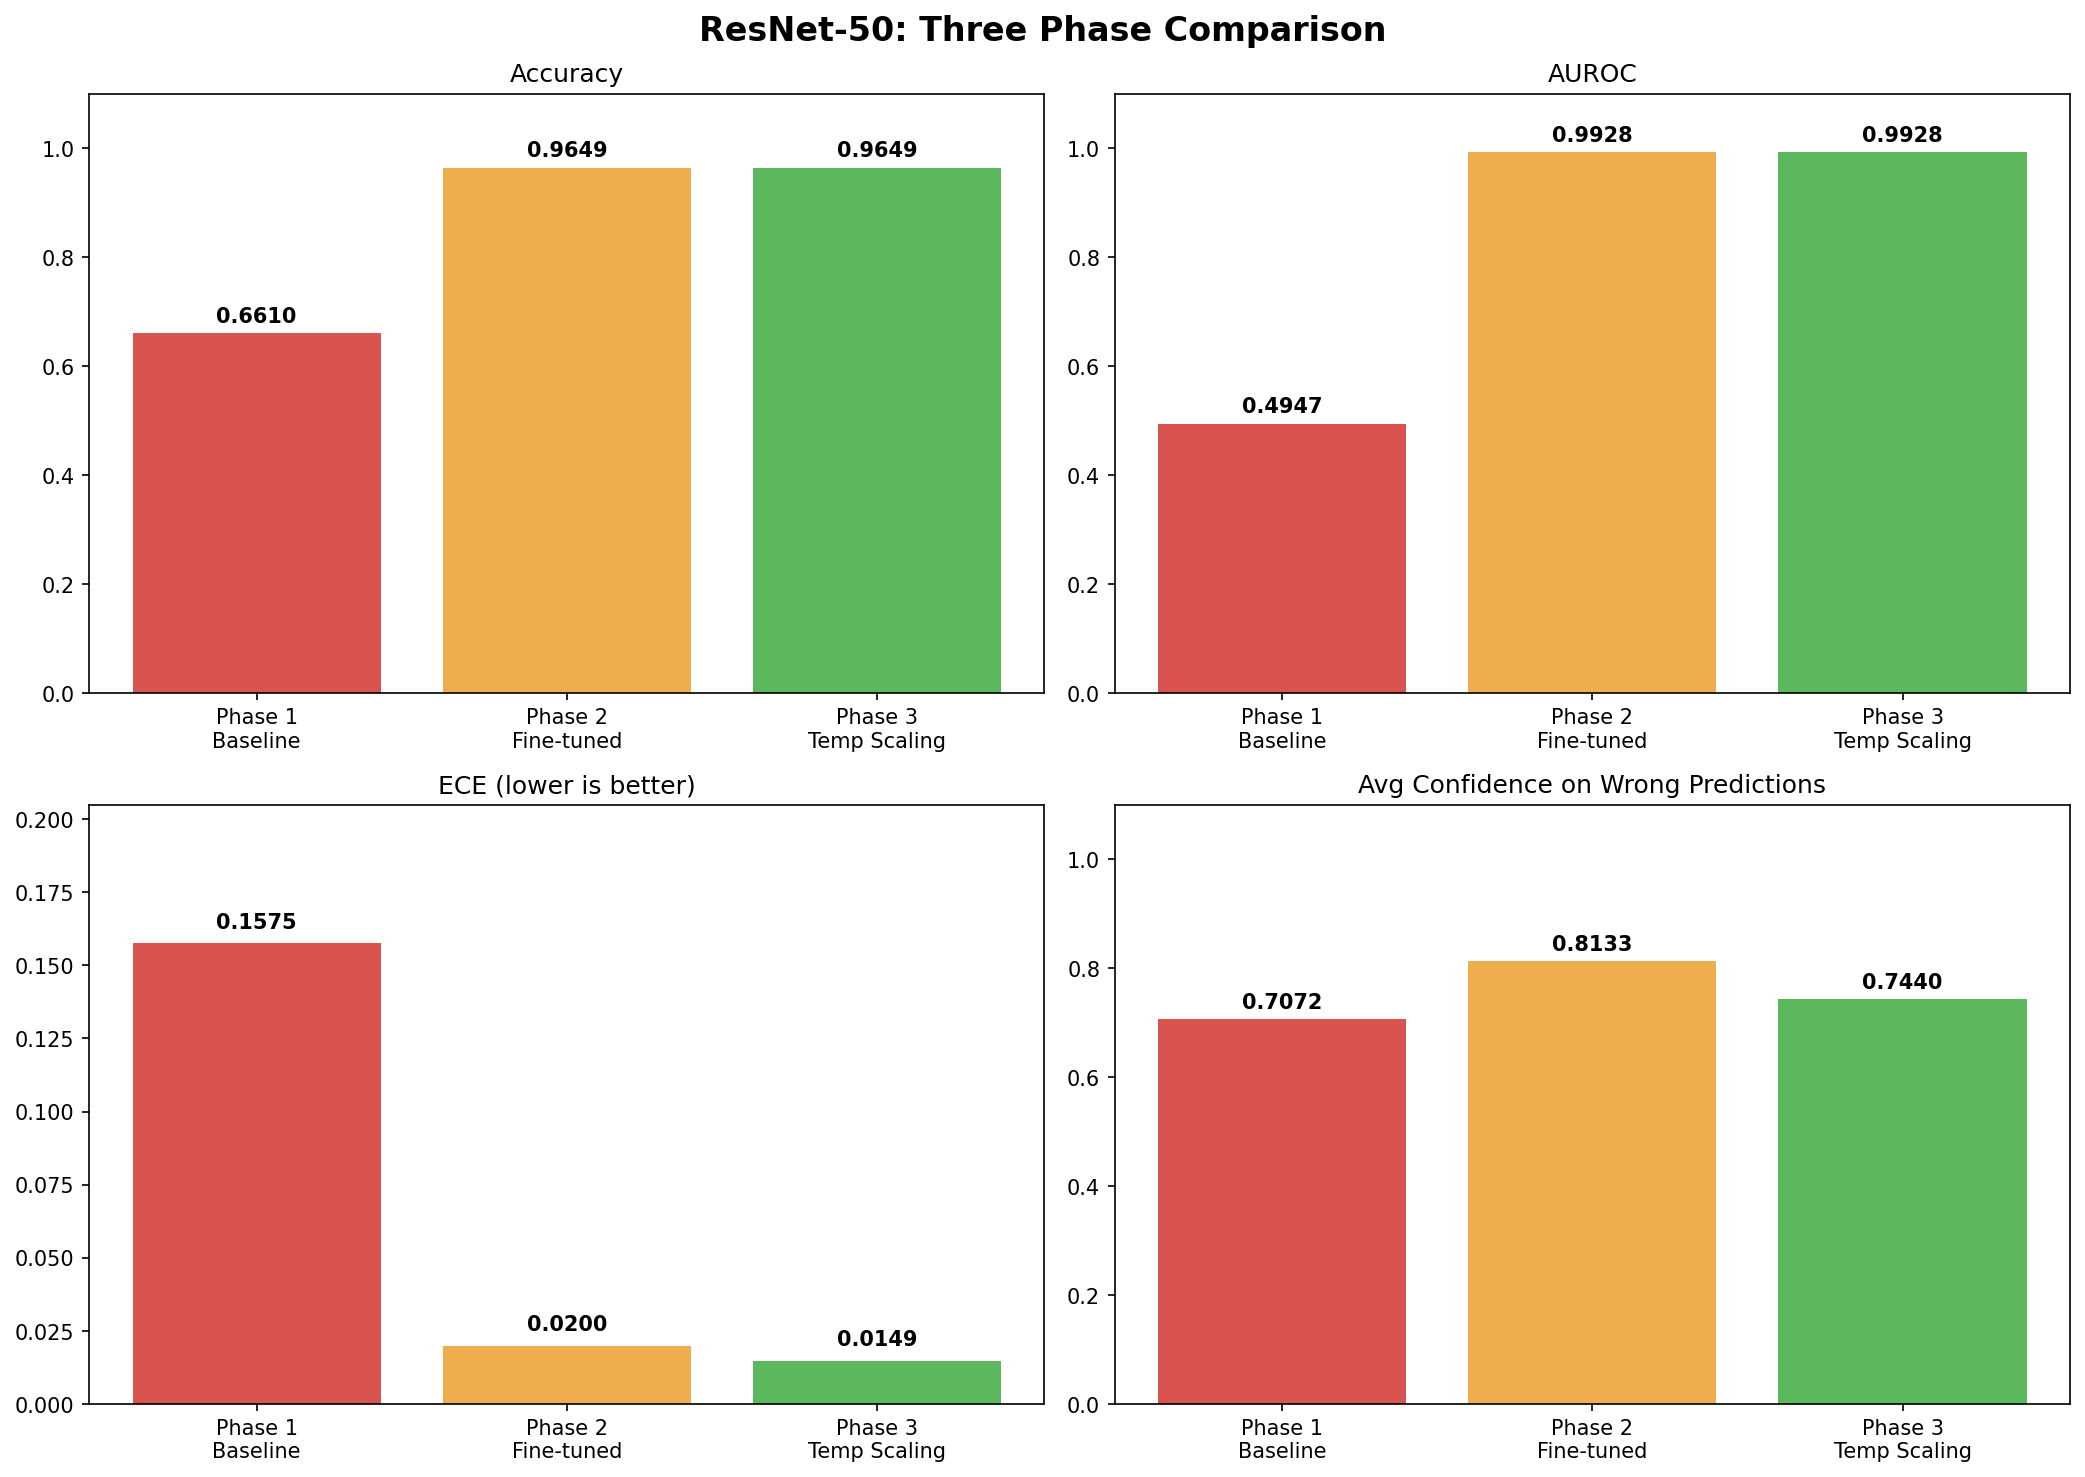

Visualization 1 saved!


In [ ]:
# ============================================
# VISUALIZATION 1: Three Phase Comparison
# ============================================

phases = ['Phase 1\nBaseline', 'Phase 2\nFine-tuned', 'Phase 3\nTemp Scaling']

accuracy = [phase1_results['accuracy'], phase2_results['accuracy'], phase3_results['accuracy']]
auroc = [phase1_results['auroc'], phase2_results['auroc'], phase3_results['auroc']]
ece = [phase1_results['ece'], phase2_results['ece'], phase3_results['ece']]
avg_conf_wrong = [phase1_results['avg_conf_wrong'], phase2_results['avg_conf_wrong'], phase3_results['avg_conf_wrong']]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ResNet-50: Three Phase Comparison', fontsize=16, fontweight='bold')

colors = ['#d9534f', '#f0ad4e', '#5cb85c']

# Accuracy
axes[0,0].bar(phases, accuracy, color=colors)
axes[0,0].set_title('Accuracy')
axes[0,0].set_ylim(0, 1.1)
for i, v in enumerate(accuracy):
    axes[0,0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# AUROC
axes[0,1].bar(phases, auroc, color=colors)
axes[0,1].set_title('AUROC')
axes[0,1].set_ylim(0, 1.1)
for i, v in enumerate(auroc):
    axes[0,1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# ECE
axes[1,0].bar(phases, ece, color=colors)
axes[1,0].set_title('ECE (lower is better)')
axes[1,0].set_ylim(0, max(ece) * 1.3)
for i, v in enumerate(ece):
    axes[1,0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Avg Confidence on Wrong Predictions
axes[1,1].bar(phases, avg_conf_wrong, color=colors)
axes[1,1].set_title('Avg Confidence on Wrong Predictions')
axes[1,1].set_ylim(0, 1.1)
for i, v in enumerate(avg_conf_wrong):
    axes[1,1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50/viz1_three_phase_comparison.png', bbox_inches='tight')
plt.show()
print("Visualization 1 saved!")

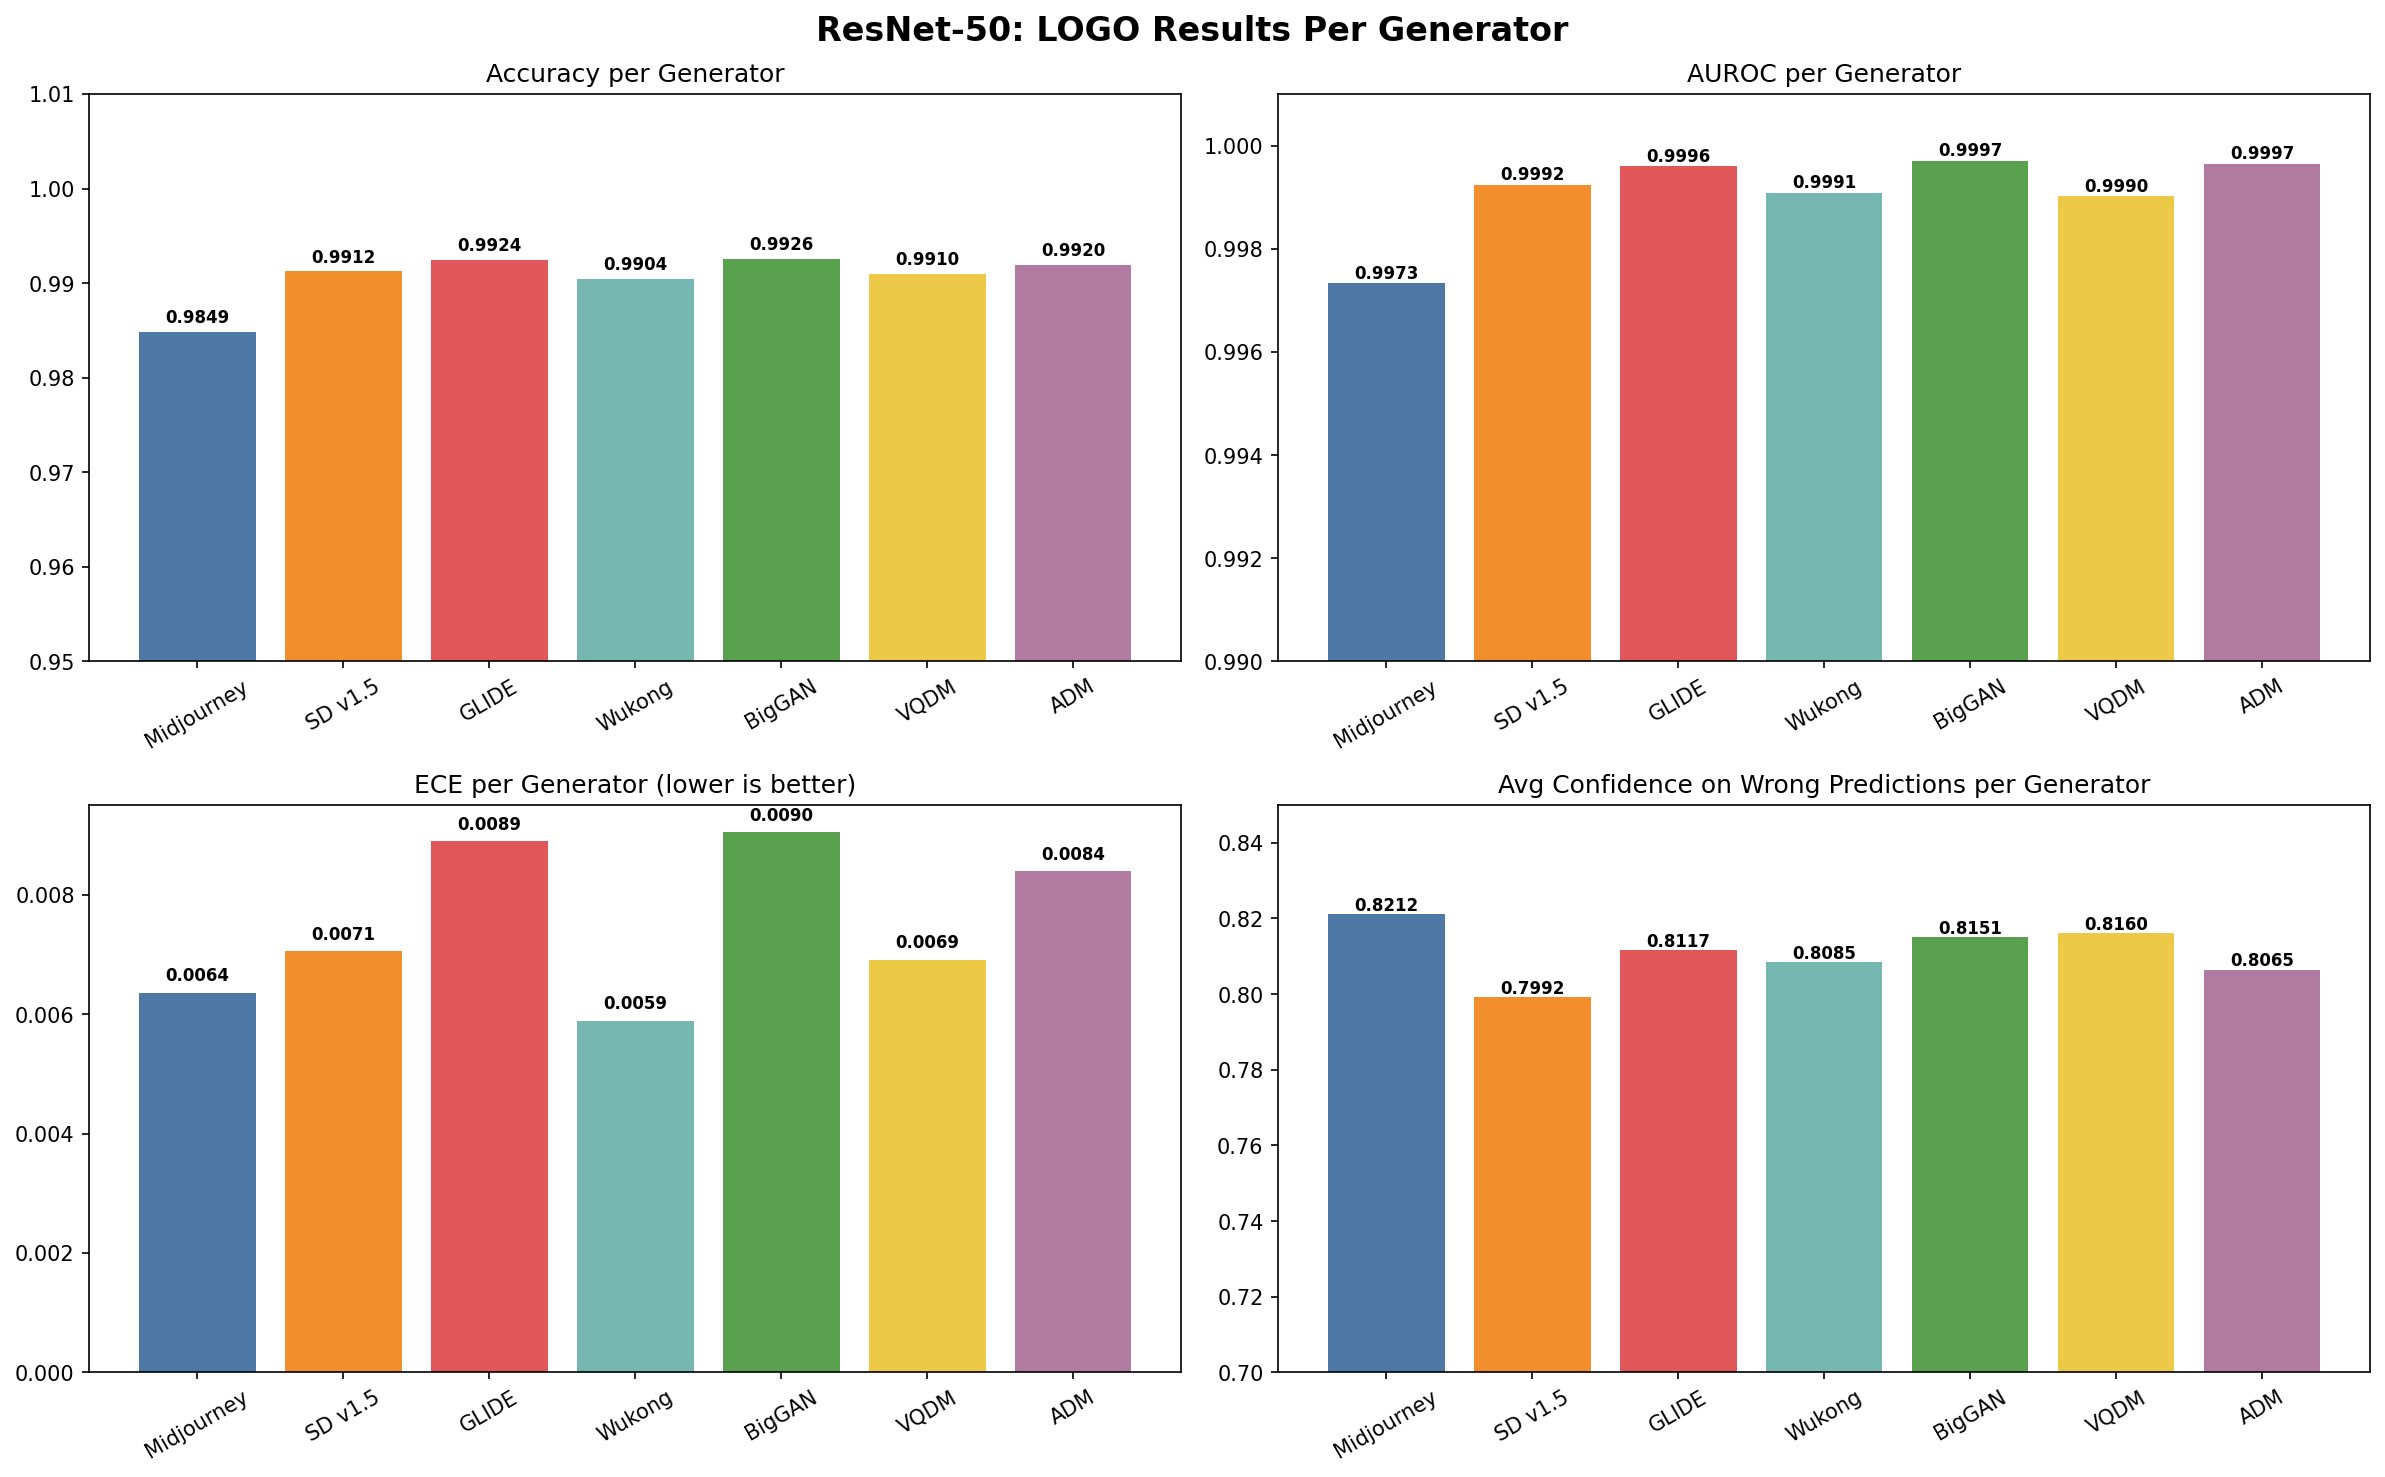

Visualization 2 saved!


In [ ]:
# ============================================
# VISUALIZATION 2: LOGO Per Generator
# ============================================

generators = list(logo_results.keys())
gen_labels = ['Midjourney', 'SD v1.5', 'GLIDE', 'Wukong', 'BigGAN', 'VQDM', 'ADM']

acc_logo = [logo_results[g]['accuracy'] for g in generators]
auroc_logo = [logo_results[g]['auroc'] for g in generators]
ece_logo = [logo_results[g]['ece'] for g in generators]
conf_wrong_logo = [logo_results[g]['avg_conf_wrong'] for g in generators]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ResNet-50: LOGO Results Per Generator', fontsize=16, fontweight='bold')

colors_logo = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1']

# Accuracy
axes[0,0].bar(gen_labels, acc_logo, color=colors_logo)
axes[0,0].set_title('Accuracy per Generator')
axes[0,0].set_ylim(0.95, 1.01)
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(acc_logo):
    axes[0,0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

# AUROC
axes[0,1].bar(gen_labels, auroc_logo, color=colors_logo)
axes[0,1].set_title('AUROC per Generator')
axes[0,1].set_ylim(0.99, 1.001)
axes[0,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(auroc_logo):
    axes[0,1].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

# ECE
axes[1,0].bar(gen_labels, ece_logo, color=colors_logo)
axes[1,0].set_title('ECE per Generator (lower is better)')
axes[1,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(ece_logo):
    axes[1,0].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

# Confidence on wrong predictions
axes[1,1].bar(gen_labels, conf_wrong_logo, color=colors_logo)
axes[1,1].set_title('Avg Confidence on Wrong Predictions per Generator')
axes[1,1].set_ylim(0.7, 0.85)
axes[1,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(conf_wrong_logo):
    axes[1,1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50/viz2_logo_per_generator.png', bbox_inches='tight')
plt.show()
print("Visualization 2 saved!")

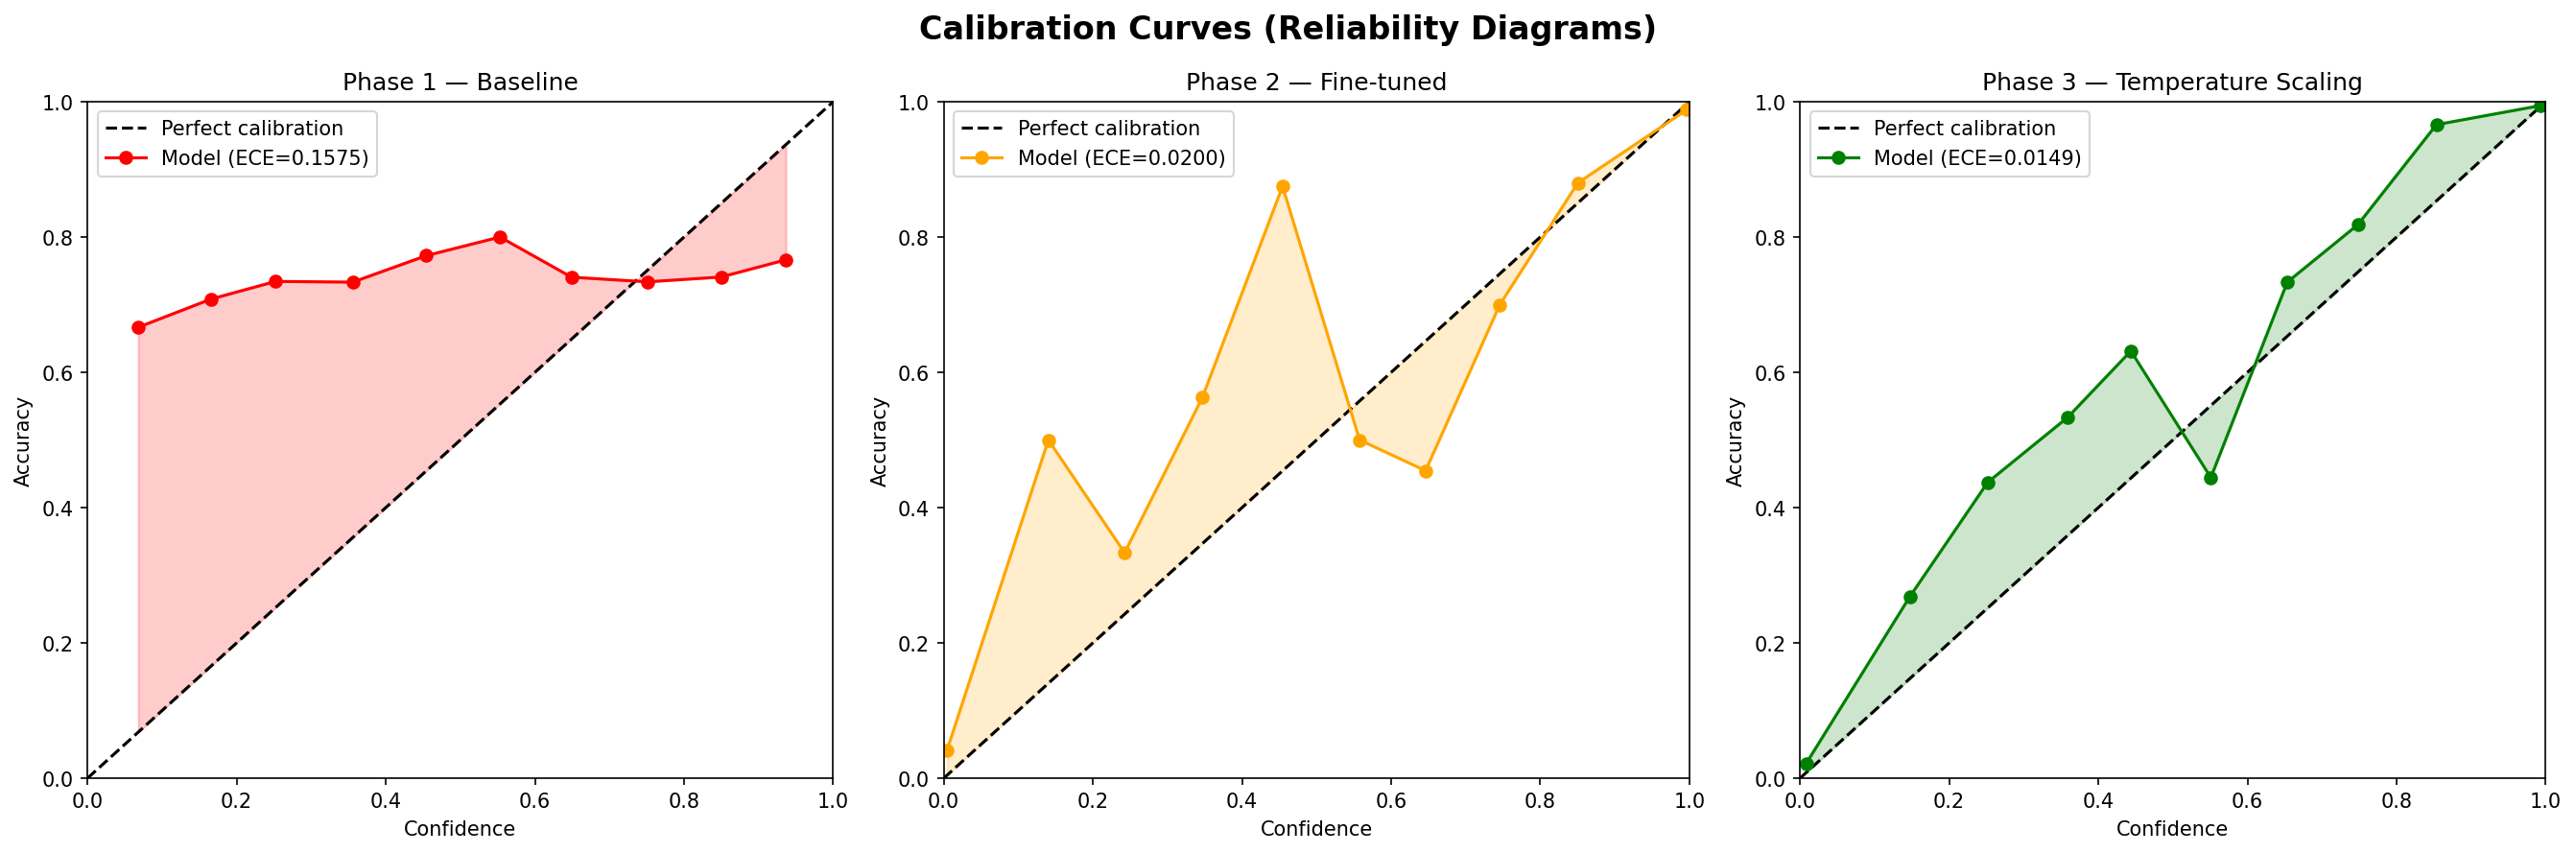

Visualization 3 saved!


In [ ]:
# ============================================
# VISUALIZATION 3: Calibration Curves
# ============================================

def compute_calibration_curve(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_accs = []
    bin_confs = []
    bin_sizes = []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() > 0:
            bin_accs.append(y_true[mask].mean())
            bin_confs.append(y_prob[mask].mean())
            bin_sizes.append(mask.sum())
        else:
            bin_accs.append(0)
            bin_confs.append((bins[i] + bins[i+1]) / 2)
            bin_sizes.append(0)
    return np.array(bin_confs), np.array(bin_accs), np.array(bin_sizes)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Calibration Curves (Reliability Diagrams)', fontsize=16, fontweight='bold')

# Phase 1
confs1, accs1, _ = compute_calibration_curve(y_true, y_pred_probs)
axes[0].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[0].plot(confs1, accs1, 'r-o', label=f'Model (ECE={phase1_results["ece"]:.4f})')
axes[0].fill_between(confs1, accs1, confs1, alpha=0.2, color='red')
axes[0].set_title('Phase 1 — Baseline')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Phase 2
confs2, accs2, _ = compute_calibration_curve(y_true, y_pred_probs_ft)
axes[1].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[1].plot(confs2, accs2, 'orange', marker='o', label=f'Model (ECE={phase2_results["ece"]:.4f})')
axes[1].fill_between(confs2, accs2, confs2, alpha=0.2, color='orange')
axes[1].set_title('Phase 2 — Fine-tuned')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

# Phase 3
confs3, accs3, _ = compute_calibration_curve(y_true, test_probs_scaled_fixed)
axes[2].plot([0,1], [0,1], 'k--', label='Perfect calibration')
axes[2].plot(confs3, accs3, 'g-o', label=f'Model (ECE={phase3_results["ece"]:.4f})')
axes[2].fill_between(confs3, accs3, confs3, alpha=0.2, color='green')
axes[2].set_title('Phase 3 — Temperature Scaling')
axes[2].set_xlabel('Confidence')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50/viz3_calibration_curves.png', bbox_inches='tight')
plt.show()
print("Visualization 3 saved!")

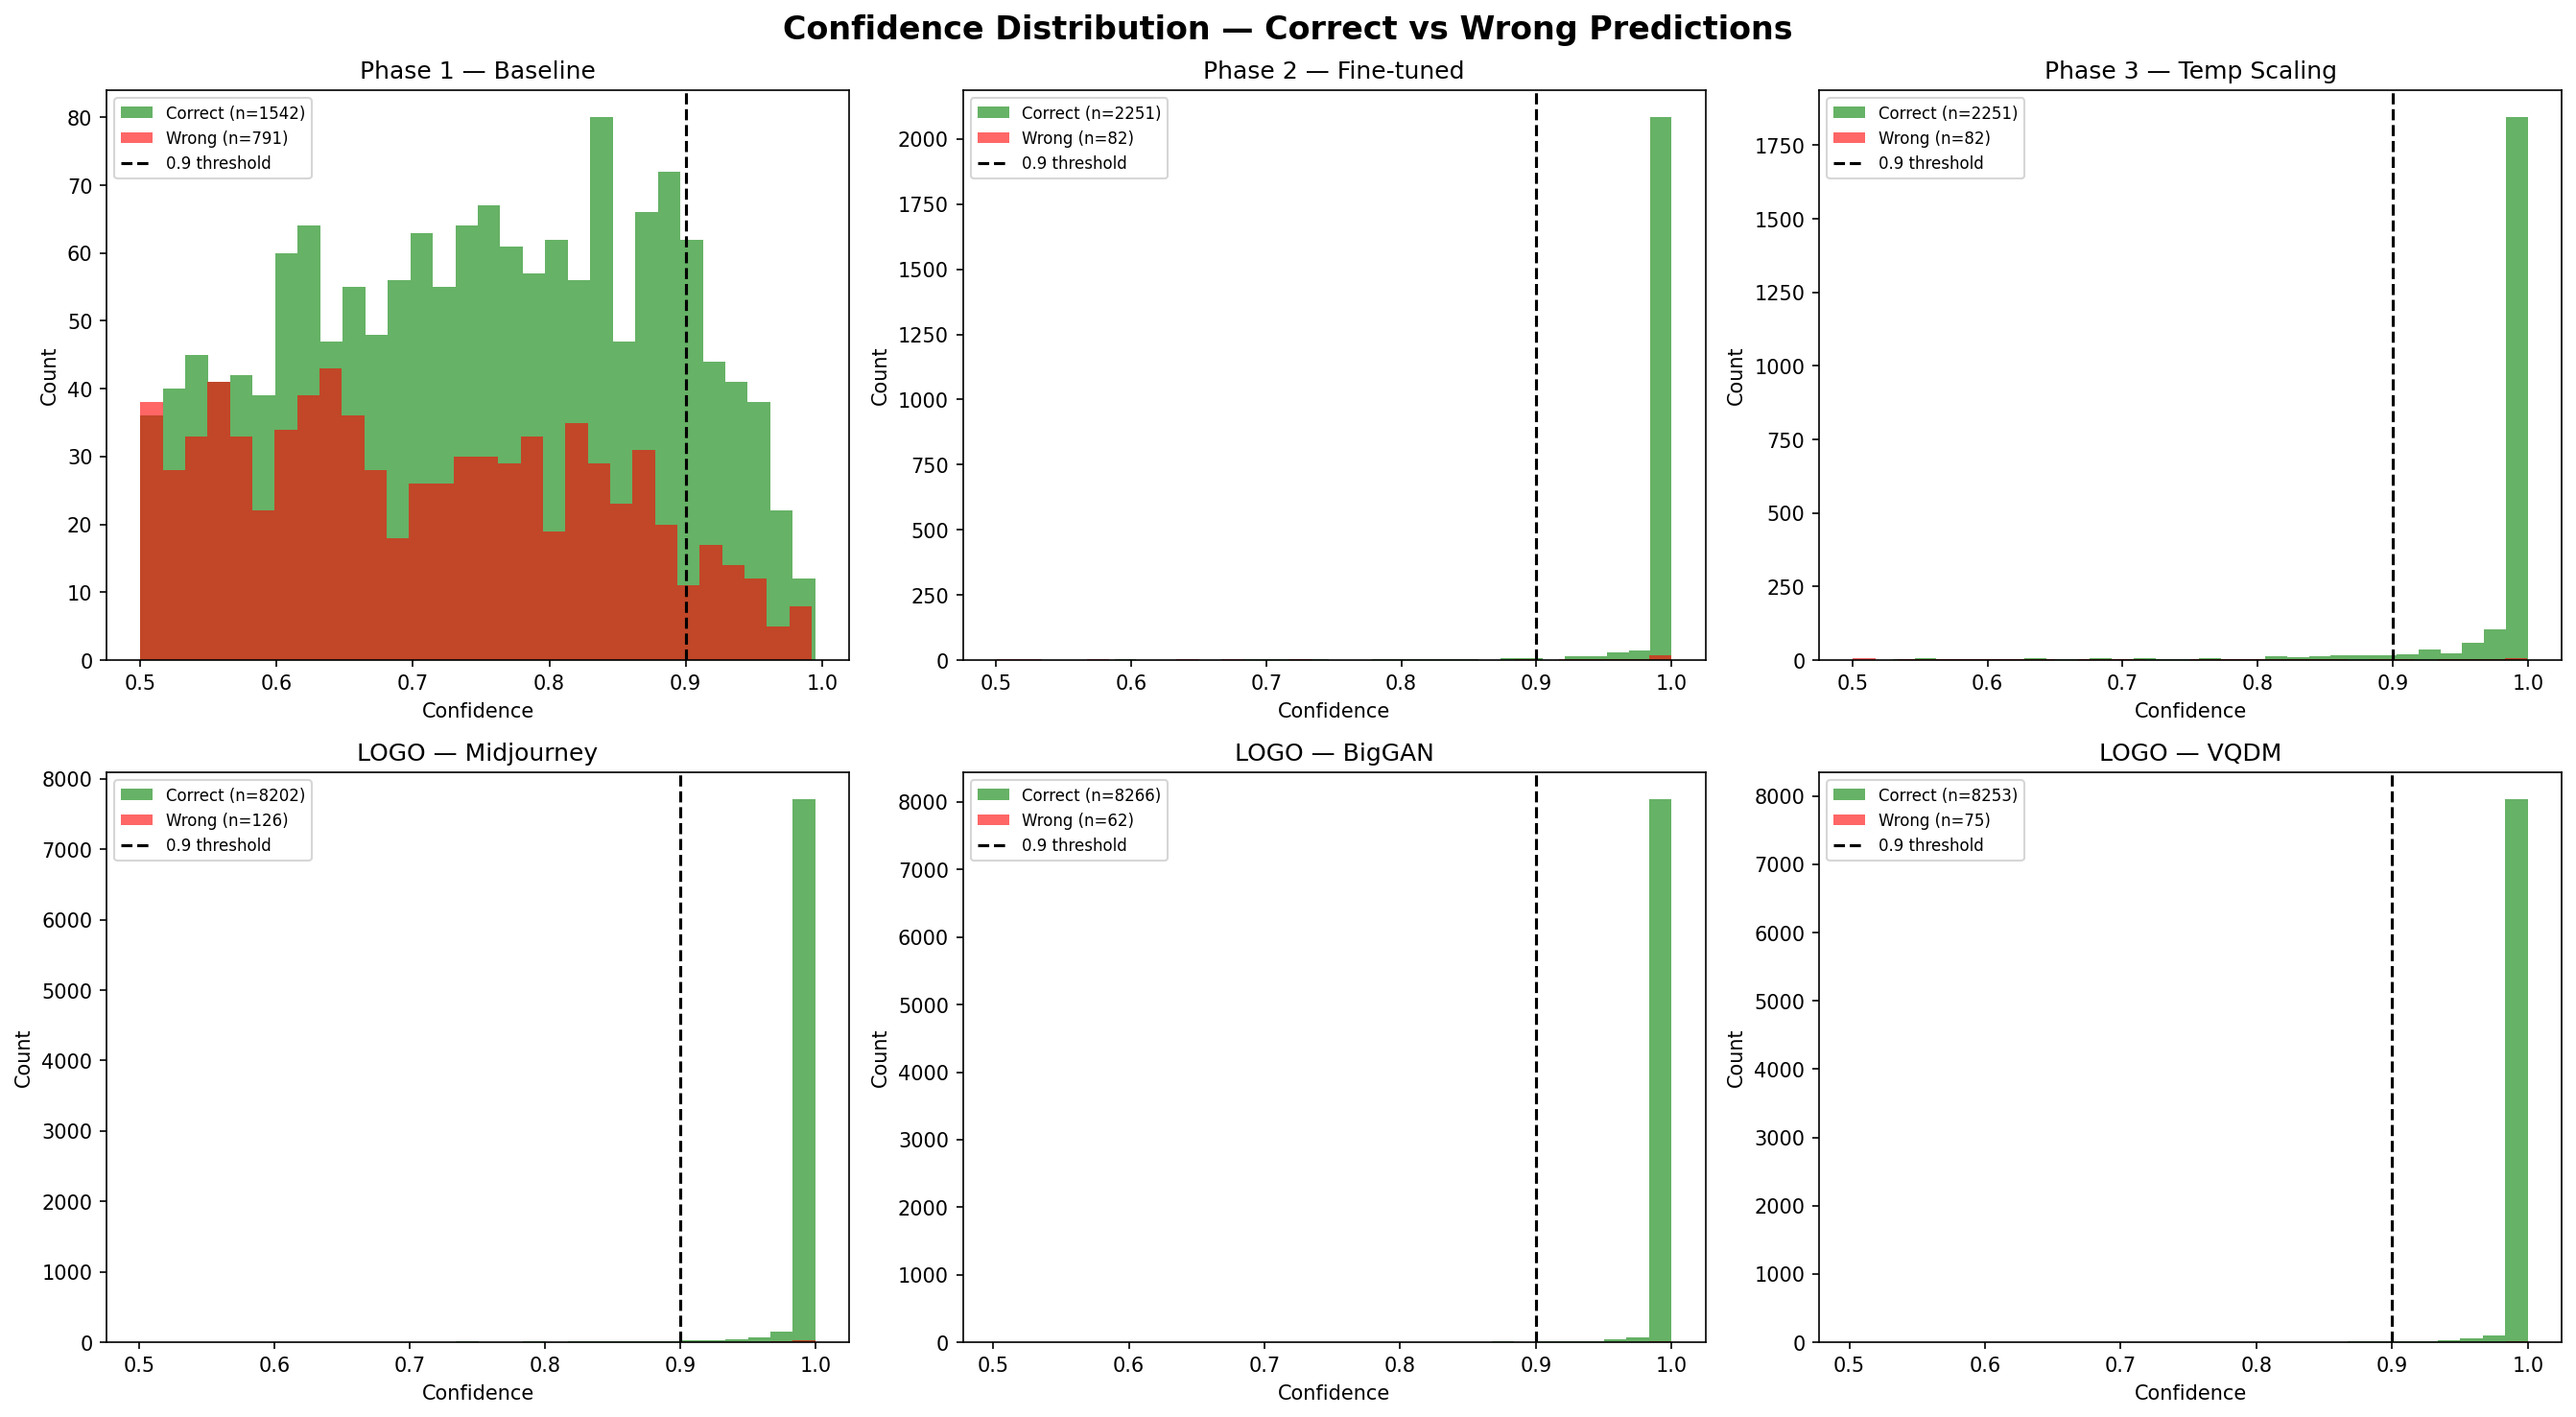

Visualization 4 saved!


In [ ]:
# ============================================
# VISUALIZATION 4: Confidence Histograms
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confidence Distribution — Correct vs Wrong Predictions', fontsize=16, fontweight='bold')

def plot_conf_hist(ax, probs, labels, title):
    pred_labels = (probs > 0.5).astype(int)
    correct_mask = pred_labels == labels
    wrong_mask = ~correct_mask

    conf = np.maximum(probs, 1 - probs)

    ax.hist(conf[correct_mask], bins=30, alpha=0.6, color='green', label=f'Correct (n={correct_mask.sum()})')
    ax.hist(conf[wrong_mask], bins=30, alpha=0.6, color='red', label=f'Wrong (n={wrong_mask.sum()})')
    ax.axvline(x=0.9, color='black', linestyle='--', label='0.9 threshold')
    ax.set_title(title)
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

# Row 1 — Three phases
plot_conf_hist(axes[0,0], y_pred_probs, y_true, 'Phase 1 — Baseline')
plot_conf_hist(axes[0,1], y_pred_probs_ft, y_true, 'Phase 2 — Fine-tuned')
plot_conf_hist(axes[0,2], test_probs_scaled_fixed, y_true, 'Phase 3 — Temp Scaling')

# Row 2 — LOGO per generator (worst 3)
# Get predictions per generator for histograms
for idx, generator in enumerate(['Midjourney', 'BigGAN', 'VQDM']):
    paths = []
    labels_gen = []
    for img in os.listdir(os.path.join(base, REAL_FOLDER)):
        paths.append(os.path.join(base, REAL_FOLDER, img))
        labels_gen.append(0)
    for img in os.listdir(os.path.join(base, generator)):
        paths.append(os.path.join(base, generator, img))
        labels_gen.append(1)

    paths = np.array(paths)
    labels_gen = np.array(labels_gen)

    ds_gen = tf.data.Dataset.from_tensor_slices((paths, labels_gen))
    ds_gen = (ds_gen
              .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(32)
              .prefetch(tf.data.AUTOTUNE))

    probs_gen = model.predict(ds_gen, verbose=0).flatten()
    plot_conf_hist(axes[1, idx], probs_gen, labels_gen, f'LOGO — {generator}')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50/viz4_confidence_histograms.png', bbox_inches='tight')
plt.show()
print("Visualization 4 saved!")

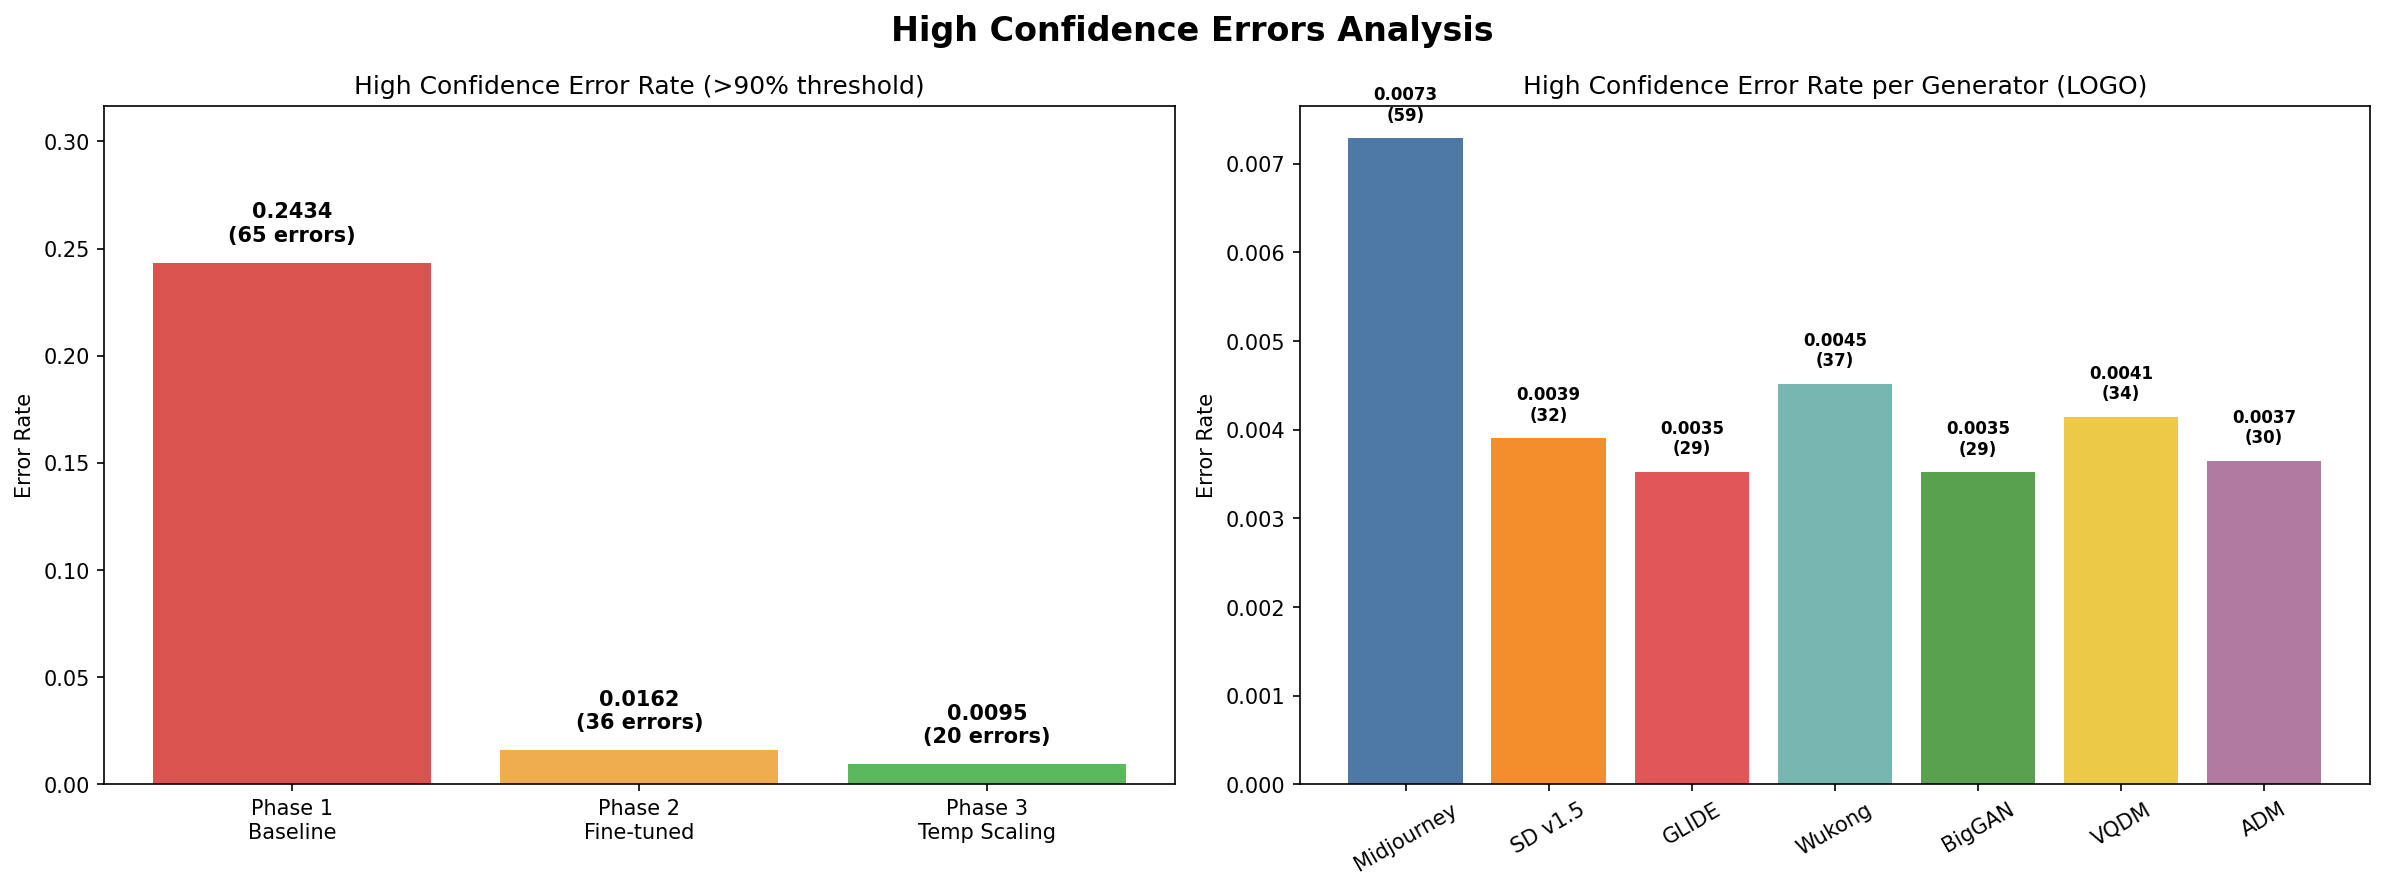

Visualization 5 saved!


In [ ]:
# ============================================
# VISUALIZATION 5: High Confidence Errors
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('High Confidence Errors Analysis', fontsize=16, fontweight='bold')

# --- Left: Three phases comparison ---
phases = ['Phase 1\nBaseline', 'Phase 2\nFine-tuned', 'Phase 3\nTemp Scaling']
hce_rates = [
    phase1_results['high_conf_error_rate'],
    phase2_results['high_conf_error_rate'],
    phase3_results['high_conf_error_rate']
]
hce_counts = [
    phase1_results['high_conf_errors'],
    phase2_results['high_conf_errors'],
    phase3_results['high_conf_errors']
]

colors = ['#d9534f', '#f0ad4e', '#5cb85c']
bars = axes[0].bar(phases, hce_rates, color=colors)
axes[0].set_title('High Confidence Error Rate (>90% threshold)')
axes[0].set_ylabel('Error Rate')
axes[0].set_ylim(0, max(hce_rates) * 1.3)
for i, (v, c) in enumerate(zip(hce_rates, hce_counts)):
    axes[0].text(i, v + 0.01, f'{v:.4f}\n({c} errors)',
                ha='center', fontweight='bold', fontsize=10)

# --- Right: LOGO per generator ---
gen_labels = ['Midjourney', 'SD v1.5', 'GLIDE', 'Wukong', 'BigGAN', 'VQDM', 'ADM']
hce_logo = [logo_results[g]['high_conf_error_rate'] for g in generators]
hce_counts_logo = [logo_results[g]['high_conf_errors'] for g in generators]

colors_logo = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc948', '#b07aa1']
axes[1].bar(gen_labels, hce_logo, color=colors_logo)
axes[1].set_title('High Confidence Error Rate per Generator (LOGO)')
axes[1].set_ylabel('Error Rate')
axes[1].tick_params(axis='x', rotation=30)
for i, (v, c) in enumerate(zip(hce_logo, hce_counts_logo)):
    axes[1].text(i, v + 0.0002, f'{v:.4f}\n({c})',
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50/viz5_high_confidence_errors.png', bbox_inches='tight')
plt.show()
print("Visualization 5 saved!")

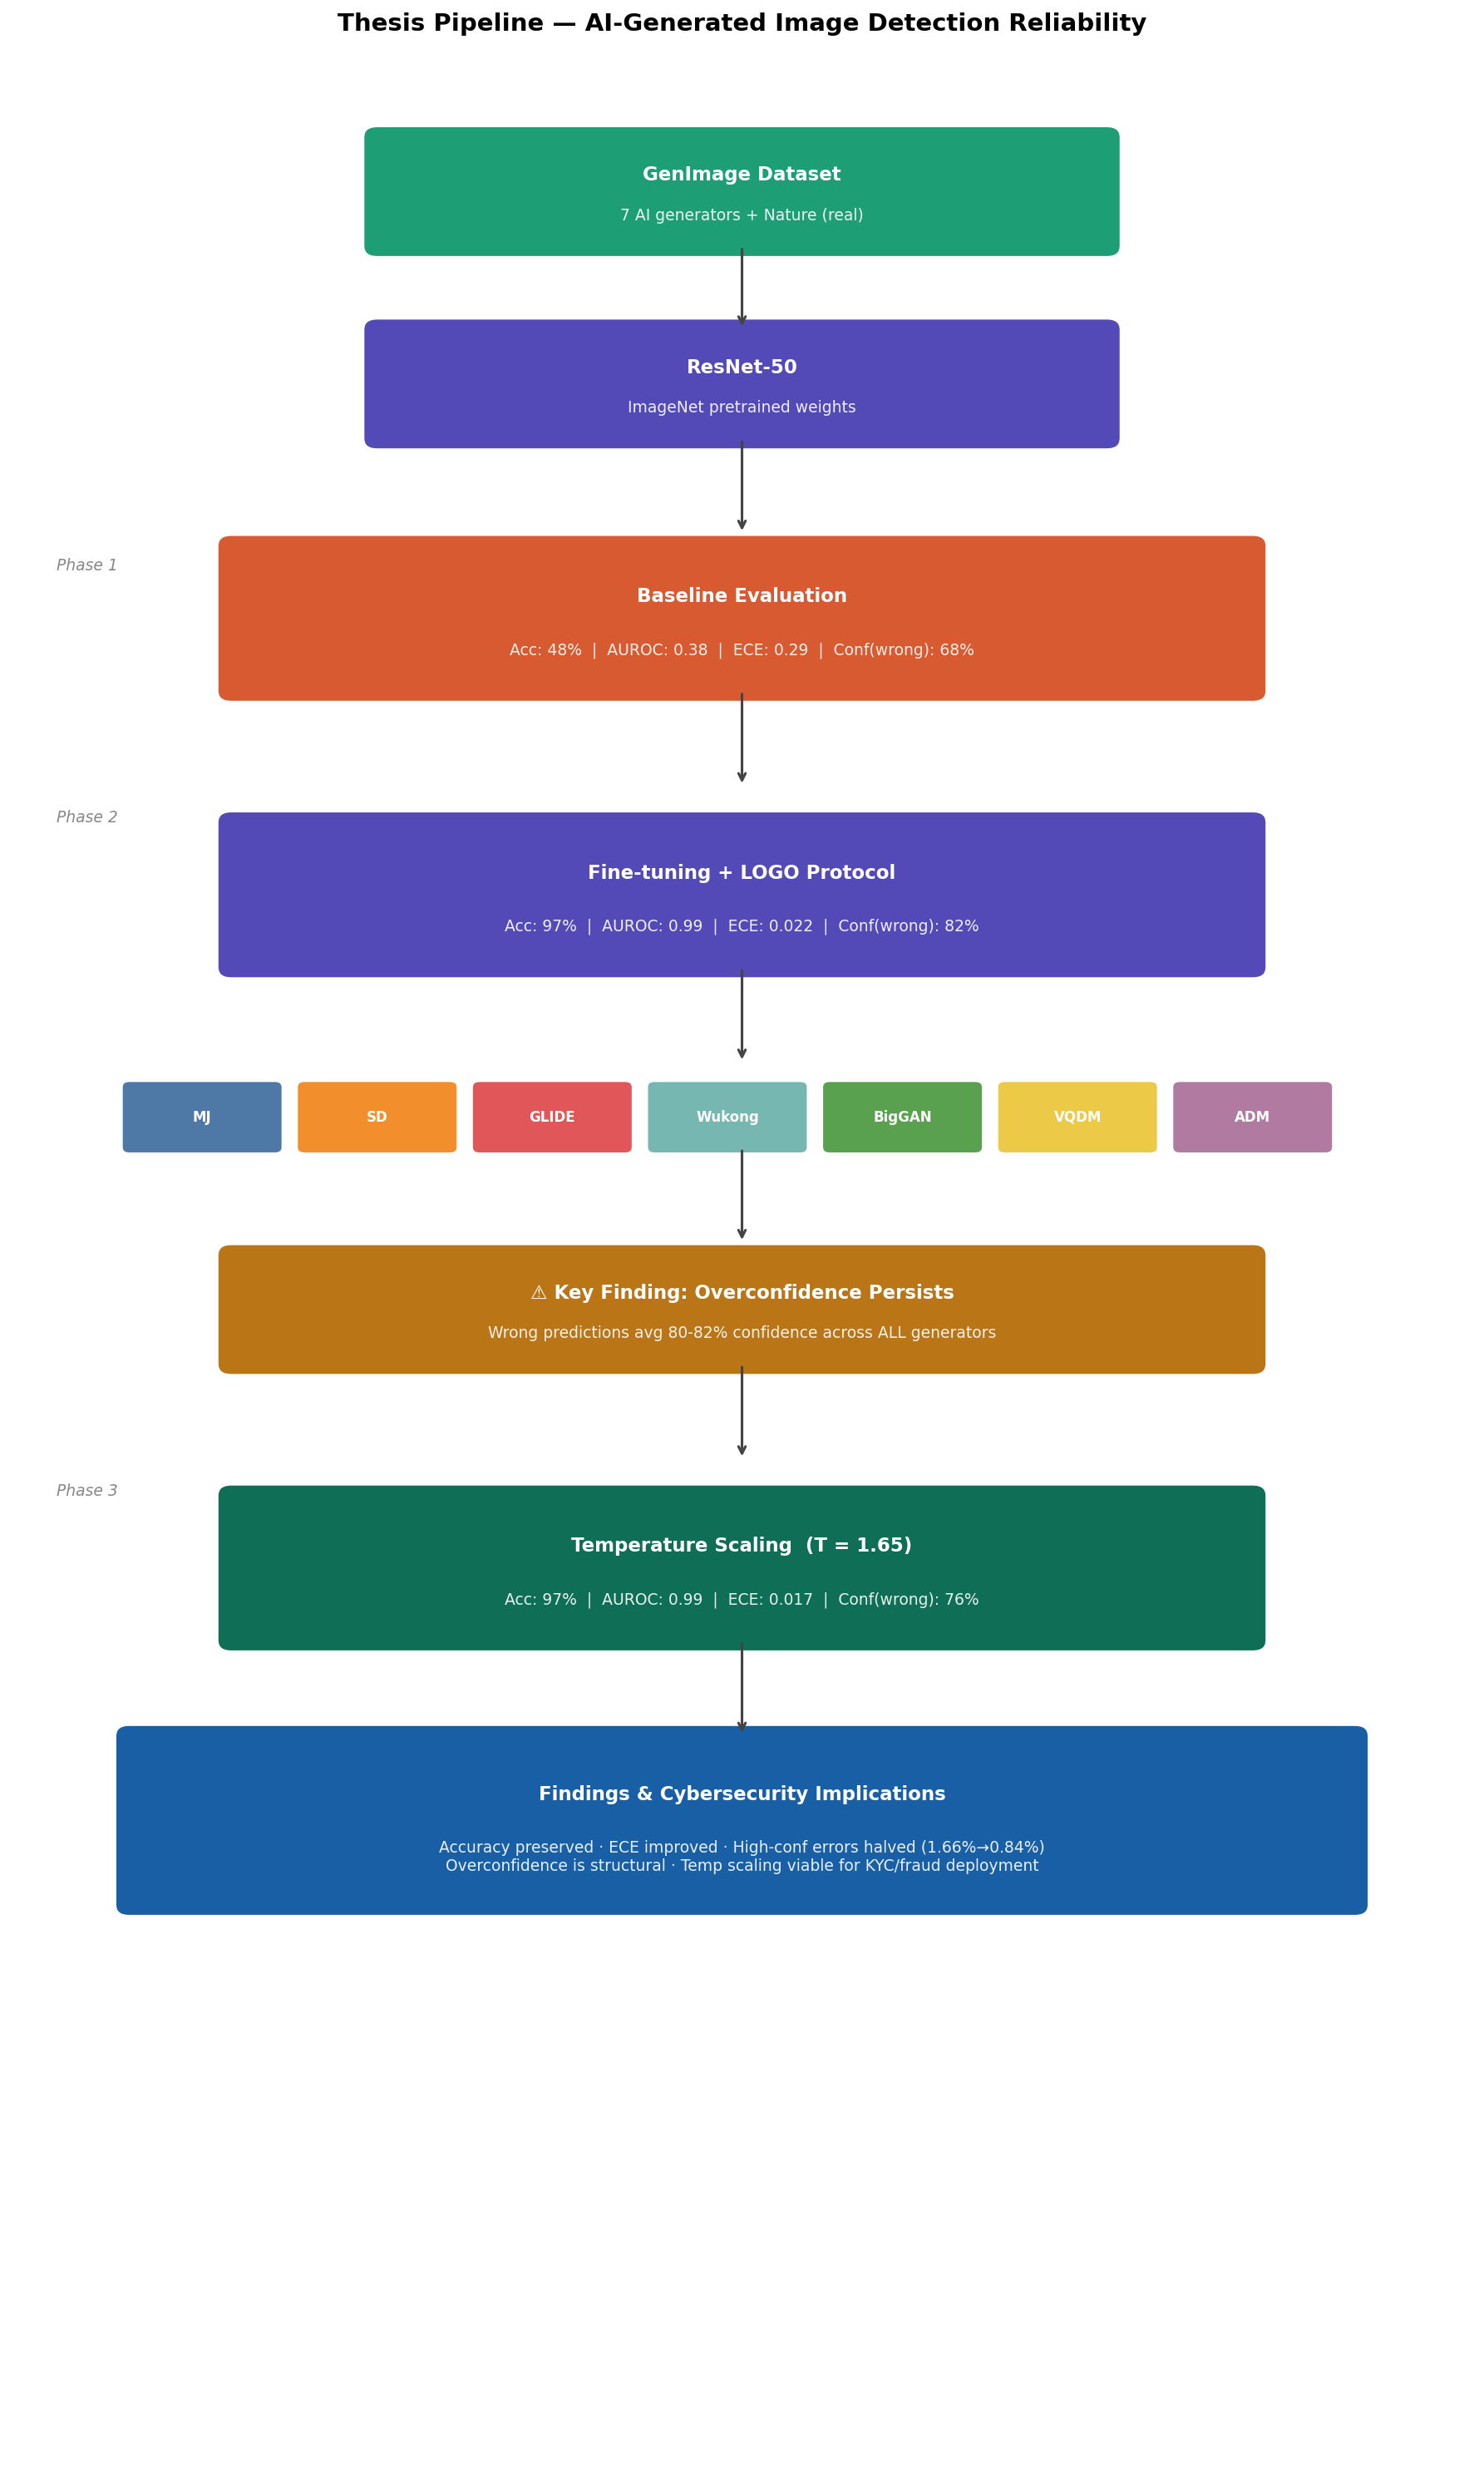

Visualization 6 saved!


In [ ]:
# ============================================
# VISUALIZATION 6: Thesis Flow Diagram
# ============================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 20))
ax.set_xlim(0, 10)
ax.set_ylim(0, 20)
ax.axis('off')
fig.patch.set_facecolor('white')

def draw_box(ax, x, y, w, h, label, sublabel='', color='#4e79a7', text_color='white'):
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor='white', linewidth=2)
    ax.add_patch(box)
    if sublabel:
        ax.text(x+w/2, y+h*0.65, label, ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color)
        ax.text(x+w/2, y+h*0.28, sublabel, ha='center', va='center',
                fontsize=9, color=text_color, alpha=0.9)
    else:
        ax.text(x+w/2, y+h/2, label, ha='center', va='center',
                fontsize=11, fontweight='bold', color=text_color)

def draw_arrow(ax, x, y1, y2):
    ax.annotate('', xy=(x, y2), xytext=(x, y1),
                arrowprops=dict(arrowstyle='->', color='#444', lw=1.5))

# Dataset
draw_box(ax, 2.5, 18.5, 5, 0.9, 'GenImage Dataset',
         '7 AI generators + Nature (real)', '#1D9E75')
draw_arrow(ax, 5, 18.5, 17.8)

# Model
draw_box(ax, 2.5, 16.9, 5, 0.9, 'ResNet-50',
         'ImageNet pretrained weights', '#534AB7')
draw_arrow(ax, 5, 16.9, 16.1)

# Phase 1
ax.text(0.3, 15.8, 'Phase 1', fontsize=9, color='#888', fontstyle='italic')
draw_box(ax, 1.5, 14.8, 7, 1.2, 'Baseline Evaluation',
         'Acc: 48%  |  AUROC: 0.38  |  ECE: 0.29  |  Conf(wrong): 68%', '#D85A30')
draw_arrow(ax, 5, 14.8, 14.0)

# Phase 2
ax.text(0.3, 13.7, 'Phase 2', fontsize=9, color='#888', fontstyle='italic')
draw_box(ax, 1.5, 12.5, 7, 1.2, 'Fine-tuning + LOGO Protocol',
         'Acc: 97%  |  AUROC: 0.99  |  ECE: 0.022  |  Conf(wrong): 82%', '#534AB7')
draw_arrow(ax, 5, 12.5, 11.7)

# LOGO generators
generators = ['MJ', 'SD', 'GLIDE', 'Wukong', 'BigGAN', 'VQDM', 'ADM']
colors_g = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948','#b07aa1']
for i, (g, c) in enumerate(zip(generators, colors_g)):
    bx = 0.8 + i * 1.2
    box = FancyBboxPatch((bx, 11.0), 1.0, 0.5, boxstyle="round,pad=0.05",
                         facecolor=c, edgecolor='white', linewidth=1)
    ax.add_patch(box)
    ax.text(bx+0.5, 11.25, g, ha='center', va='center', fontsize=8,
            fontweight='bold', color='white')
draw_arrow(ax, 5, 11.0, 10.2)

# Overconfidence finding
draw_box(ax, 1.5, 9.2, 7, 0.9, '⚠ Key Finding: Overconfidence Persists',
         'Wrong predictions avg 80-82% confidence across ALL generators', '#BA7517')
draw_arrow(ax, 5, 9.2, 8.4)

# Phase 3
ax.text(0.3, 8.1, 'Phase 3', fontsize=9, color='#888', fontstyle='italic')
draw_box(ax, 1.5, 6.9, 7, 1.2, 'Temperature Scaling  (T = 1.65)',
         'Acc: 97%  |  AUROC: 0.99  |  ECE: 0.017  |  Conf(wrong): 76%', '#0F6E56')
draw_arrow(ax, 5, 6.9, 6.1)

# Final findings
draw_box(ax, 0.8, 4.7, 8.4, 1.4, 'Findings & Cybersecurity Implications',
         'Accuracy preserved · ECE improved · High-conf errors halved (1.66%→0.84%)\nOverconfidence is structural · Temp scaling viable for KYC/fraud deployment',
         '#185FA5')

ax.set_title('Thesis Pipeline — AI-Generated Image Detection Reliability',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis_resnet50/viz6_thesis_flow_diagram.png',
            bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print("Visualization 6 saved!")